# Transformers: ejemplos guiados y demostraciones

Este cuaderno está pensado para **mostrar** cómo funcionan los Transformers de forma visual y paso a paso.

Qué incluye:
- embeddings;
- positional encoding;
- self-attention con ejemplo numérico;
- máscaras de padding y causalidad;
- multi-head attention;
- bloque encoder;
- ejemplo final de **clasificación**;
- ejemplo final de **generación de texto**.

No hay apartados de “hazlo tú”: todo está montado como ejemplos mostrados y explicados.

## Cómo leer este notebook

La idea es ir ejecutando las celdas en orden y fijarse en:
- qué entra a cada bloque;
- qué forma tienen los tensores;
- cómo cambian los pesos de atención;
- cómo un Transformer pequeño puede aprender una tarea sencilla de texto.

Los ejemplos finales están hechos para ejecutarse en CPU en poco tiempo.

In [1]:

import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

def simple_tokenize(text):
    return text.lower().replace(",", "").replace(".", "").split()

def build_vocab(texts, specials=("<pad>", "<unk>", "<bos>", "<eos>")):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))
    vocab = {tok: idx for idx, tok in enumerate(specials)}
    for tok, _ in counter.most_common():
        if tok not in vocab:
            vocab[tok] = len(vocab)
    inv_vocab = {idx: tok for tok, idx in vocab.items()}
    return vocab, inv_vocab

def encode(text, vocab):
    return [vocab.get(tok, vocab["<unk>"]) for tok in simple_tokenize(text)]

def decode(ids, inv_vocab):
    return " ".join(inv_vocab.get(i, "<unk>") for i in ids)

def plot_matrix(mat, xlabels=None, ylabels=None, title="Matriz"):
    mat = np.array(mat)
    plt.figure(figsize=(6, 4))
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    if xlabels is not None:
        plt.xticks(range(len(xlabels)), xlabels, rotation=45, ha="right")
    if ylabels is not None:
        plt.yticks(range(len(ylabels)), ylabels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_attention(weights, tokens, title="Atención"):
    plot_matrix(weights, xlabels=tokens, ylabels=tokens, title=title)

print("Semilla fijada:", SEED)

Dispositivo: cpu
Semilla fijada: 7


/home/enrique/flower/Flower ejemplo/.fl_ejemplo/lib/python3.9/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


# 1. Embeddings

Un Transformer no trabaja con palabras “tal cual”.  
Primero transforma cada token en un **vector denso** de números reales.

La idea intuitiva es:
- cada palabra pasa a ser una fila de una tabla de embeddings;
- palabras distintas tienen vectores distintos;
- esos vectores se aprenden durante el entrenamiento.

In [2]:

texts = [
    "el gato duerme",
    "el perro corre",
    "el gato corre rapido",
]

vocab, inv_vocab = build_vocab(texts)
print("Vocabulario:", vocab)

embedding = nn.Embedding(num_embeddings=len(vocab), embedding_dim=8)

sentence = "el gato corre"
token_ids = torch.tensor(encode(sentence, vocab))
embedded = embedding(token_ids)

print("\nFrase:", sentence)
print("IDs:", token_ids.tolist())
print("Shape embeddings:", tuple(embedded.shape))
print("Embeddings:")
print(embedded.detach())

Vocabulario: {'<pad>': 0, '<unk>': 1, '<bos>': 2, '<eos>': 3, 'el': 4, 'gato': 5, 'corre': 6, 'duerme': 7, 'perro': 8, 'rapido': 9}

Frase: el gato corre
IDs: [4, 5, 6]
Shape embeddings: (3, 8)
Embeddings:
tensor([[-0.0835, -0.0235,  0.1744,  2.2983,  0.9571, -0.6619, -0.8285, -0.6057],
        [-1.4013,  1.2973,  1.6409, -1.0567, -0.2616, -0.2501,  0.5011,  0.2600],
        [-0.1782, -0.2595, -0.0145, -0.3839, -2.9662, -1.0606, -0.3090,  0.9343]])


### Qué observar

Cada token se convierte en un vector de dimensión 6.  
Si la frase tiene 3 tokens, la salida tiene forma **(3, 6)**.

Eso significa:
- 3 filas: una por token;
- 6 columnas: las características latentes aprendidas.

# 2. Positional Encoding

La atención, por sí sola, no sabe si una palabra iba al principio o al final.  
Por eso se añade una señal de posición al embedding.

Aquí mostramos el esquema sinusoidal clásico.

Shape positional encoding: (12, 8)
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00],
        [-7.5680e-01, -6.5364e-01,  3.8942e-01,  9.2106e-01,  3.9989e-02,
          9.9920e-01,  4.0000e-03,  9.9999e-01]])


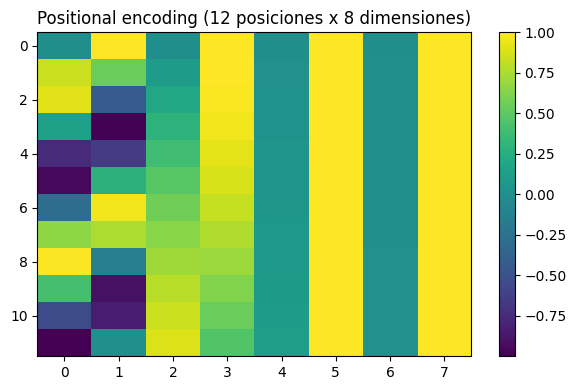

In [3]:

def positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

max_len = 12
d_model = 8
pe = positional_encoding(max_len=max_len, d_model=d_model)

print("Shape positional encoding:", tuple(pe.shape))
print(pe[:5])

plot_matrix(pe[:12].numpy(), title="Positional encoding (12 posiciones x 8 dimensiones)")

### Qué observar

Dos tokens con el mismo embedding base pueden representarse distinto si están en posiciones distintas, porque:
- al embedding del token se le suma su vector posicional;
- la red puede usar esa información para distinguir orden.

Embeddings puros shape: (4, 8)
Embeddings + posición shape: (4, 8)


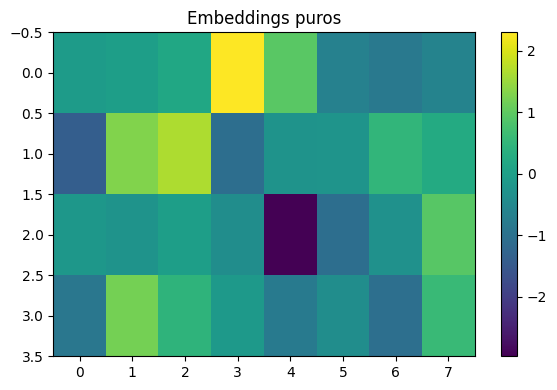

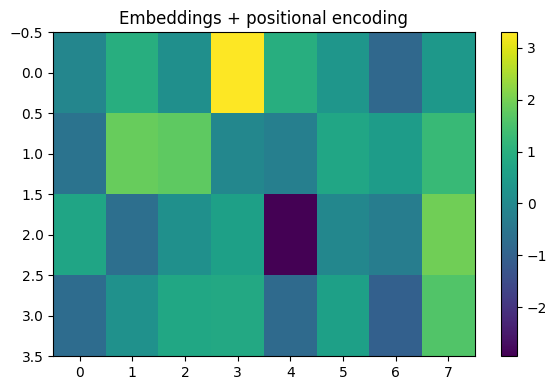

In [4]:

sentence = "el gato corre rapido"
ids = torch.tensor(encode(sentence, vocab))
tok_emb = embedding(ids)
pos = pe[:len(ids)]
combined = tok_emb + pos

print("Embeddings puros shape:", tuple(tok_emb.shape))
print("Embeddings + posición shape:", tuple(combined.shape))

plot_matrix(tok_emb.detach().numpy(), title="Embeddings puros")
plot_matrix(combined.detach().numpy(), title="Embeddings + positional encoding")

# 3. Self-Attention paso a paso

En self-attention, cada token genera tres vectores:
- **Q**: Query;
- **K**: Key;
- **V**: Value.

La atención compara cada Query con todas las Keys, obtiene pesos y usa esos pesos para mezclar las Values.

Q =
 tensor([[2., 0.],
        [0., 3.],
        [1., 2.],
        [2., 2.]])

K =
 tensor([[2., 1.],
        [0., 3.],
        [1., 3.],
        [2., 2.]])

V =
 tensor([[2.0000, 1.0000],
        [0.5000, 2.0000],
        [1.5000, 1.0000],
        [2.5000, 3.0000]])

Scores =
 tensor([[2.8284, 0.0000, 1.4142, 2.8284],
        [2.1213, 6.3640, 6.3640, 4.2426],
        [2.8284, 4.2426, 4.9497, 4.2426],
        [4.2426, 4.2426, 5.6569, 5.6569]])

Pesos de atención =
 tensor([[0.4344, 0.0257, 0.1056, 0.4344],
        [0.0067, 0.4686, 0.4686, 0.0562],
        [0.0569, 0.2341, 0.4748, 0.2341],
        [0.0978, 0.0978, 0.4022, 0.4022]])

Salida =
 tensor([[2.1259, 1.8944],
        [1.0910, 1.5809],
        [1.5285, 1.7024],
        [1.8533, 1.9022]])


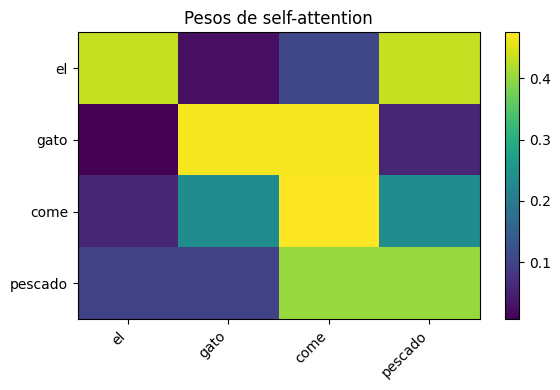

In [5]:

tokens = ["el", "gato", "come", "pescado"]

X = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],  # el
    [0.0, 2.0, 0.0, 1.0],  # gato
    [1.0, 1.0, 0.0, 1.0],  # come
    [0.0, 1.0, 2.0, 1.0],  # pescado
])

WQ = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [0.0, 1.0],
])

WK = torch.tensor([
    [1.0, 1.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [0.0, 1.0],
])

WV = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [0.5, 0.0],
])

Q = X @ WQ
K = X @ WK
V = X @ WV

scores = Q @ K.T / math.sqrt(Q.shape[-1])
weights = torch.softmax(scores, dim=-1)
output = weights @ V

print("Q =\n", Q)
print("\nK =\n", K)
print("\nV =\n", V)
print("\nScores =\n", scores)
print("\nPesos de atención =\n", weights)
print("\nSalida =\n", output)

plot_attention(weights.detach().numpy(), tokens, title="Pesos de self-attention")

### Qué observar

Cada fila de la matriz de pesos suma aproximadamente 1.  
Cada fila indica **a qué tokens mira** un token concreto.

Por ejemplo:
- la fila del token 3 muestra cuánto atiende a `el`, `gato`, `come` y `pescado`;
- la salida final de cada token es una mezcla ponderada de las `V`.

# 4. Máscaras: padding y causal mask

Las máscaras sirven para impedir que ciertos tokens sean atendidos.

Hay dos casos muy comunes:
- **padding mask**: ignora relleno `<pad>`;
- **causal mask**: en generación, un token no puede mirar al futuro.

Scores originales:
 tensor([[ 1.0000,  2.0000,  3.0000,  4.0000],
        [ 0.5000,  1.0000,  1.5000,  2.0000],
        [ 2.0000,  1.0000,  0.0000, -1.0000],
        [ 1.0000,  0.0000,  1.0000,  0.0000]])

Pesos con padding mask:
 tensor([[0.0900, 0.2447, 0.6652, 0.0000],
        [0.1863, 0.3072, 0.5065, 0.0000],
        [0.6652, 0.2447, 0.0900, 0.0000],
        [0.4223, 0.1554, 0.4223, 0.0000]])


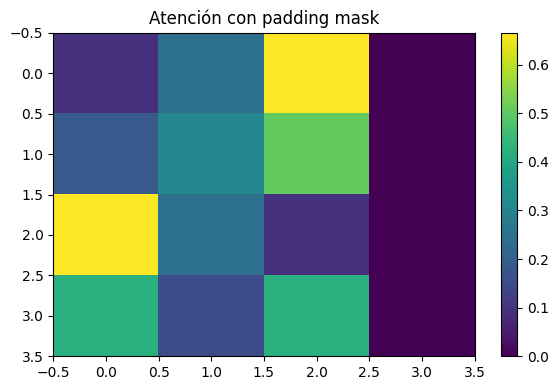

In [6]:

scores_demo = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [0.5, 1.0, 1.5, 2.0],
    [2.0, 1.0, 0.0, -1.0],
    [1.0, 0.0, 1.0, 0.0],
])

padding_mask = torch.tensor([1, 1, 1, 0]).bool()  # último token es padding
masked_scores = scores_demo.clone()
masked_scores[:, ~padding_mask] = -1e9
padding_weights = torch.softmax(masked_scores, dim=-1)

print("Scores originales:\n", scores_demo)
print("\nPesos con padding mask:\n", padding_weights)

plot_matrix(padding_weights.numpy(), title="Atención con padding mask")

Causal mask (True = bloqueado):
 tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

Pesos con causal mask:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0624, 0.9376, 0.0000, 0.0000, 0.0000],
        [0.0646, 0.5976, 0.3378, 0.0000, 0.0000],
        [0.1171, 0.1826, 0.5350, 0.1653, 0.0000],
        [0.1912, 0.4844, 0.2454, 0.0363, 0.0427]])


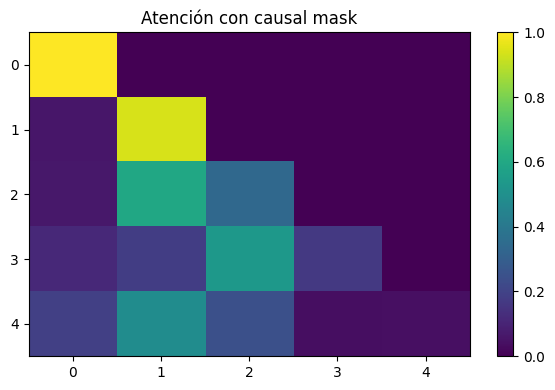

In [7]:

L = 5
causal_mask = torch.triu(torch.ones(L, L), diagonal=1).bool()

causal_scores = torch.randn(L, L)
causal_scores_masked = causal_scores.masked_fill(causal_mask, -1e9)
causal_weights = torch.softmax(causal_scores_masked, dim=-1)

print("Causal mask (True = bloqueado):\n", causal_mask.int())
print("\nPesos con causal mask:\n", causal_weights)

plot_matrix(causal_weights.numpy(), title="Atención con causal mask")

### Qué observar

En la máscara causal, por encima de la diagonal aparece la parte “prohibida”.  
Eso obliga a que la posición `t` solo use información de posiciones `<= t`.

# 5. Multi-Head Attention

En lugar de una sola atención, se usan varias cabezas en paralelo.

Cada cabeza puede aprender relaciones distintas:
- una puede centrarse en cercanía;
- otra en dependencias más largas;
- otra en concordancias o patrones semánticos.

Shape entrada: (4, 8)
Shape por cabeza Q: (2, 4, 4)
Shape salida concatenada: (4, 8)


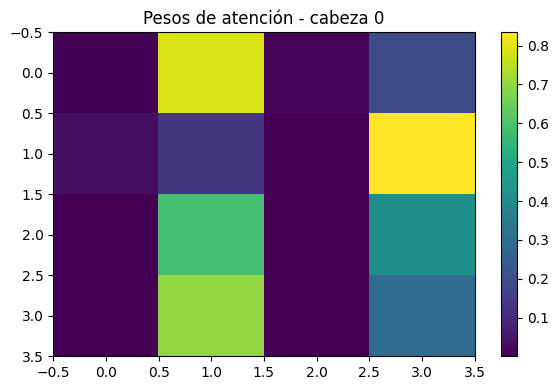

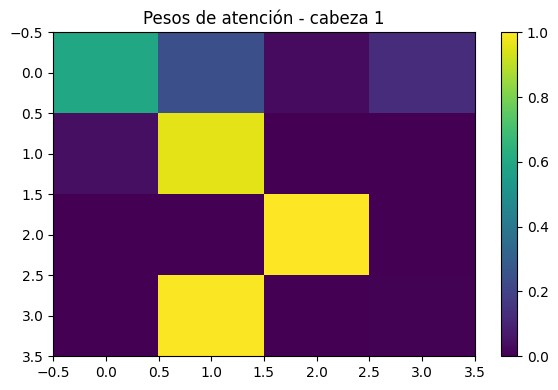

In [8]:

d_model = 8
n_heads = 2
head_dim = d_model // n_heads

X = torch.randn(4, d_model)

WQ = torch.randn(d_model, d_model)
WK = torch.randn(d_model, d_model)
WV = torch.randn(d_model, d_model)

Q = X @ WQ
K = X @ WK
V = X @ WV

Qh = Q.view(4, n_heads, head_dim).transpose(0, 1)  # (heads, seq, head_dim)
Kh = K.view(4, n_heads, head_dim).transpose(0, 1)
Vh = V.view(4, n_heads, head_dim).transpose(0, 1)

head_outputs = []
head_weights = []

for h in range(n_heads):
    scores = Qh[h] @ Kh[h].T / math.sqrt(head_dim)
    weights = torch.softmax(scores, dim=-1)
    out = weights @ Vh[h]
    head_outputs.append(out)
    head_weights.append(weights)

concat_out = torch.cat(head_outputs, dim=-1)

print("Shape entrada:", tuple(X.shape))
print("Shape por cabeza Q:", tuple(Qh.shape))
print("Shape salida concatenada:", tuple(concat_out.shape))

for h, w in enumerate(head_weights):
    plot_matrix(w.detach().numpy(), title=f"Pesos de atención - cabeza {h}")

### Qué observar

Cada cabeza produce su propia matriz de atención.  
Después:
- las salidas de las cabezas se concatenan;
- una proyección lineal mezcla esa información.

# 6. Residual + LayerNorm + Feed Forward Network

Un bloque Transformer no es solo atención.  
Normalmente sigue este patrón:

1. atención;
2. suma residual;
3. layer normalization;
4. red feed-forward;
5. otra suma residual;
6. otra normalization.

In [9]:

x = torch.randn(2, 4, 8)
attn_out = torch.randn(2, 4, 8)

ln1 = nn.LayerNorm(8)
ln2 = nn.LayerNorm(8)

ffn = nn.Sequential(
    nn.Linear(8, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
)

h1 = ln1(x + attn_out)
h2 = ln2(h1 + ffn(h1))

print("Shape x:", tuple(x.shape))
print("Shape tras residual + norm 1:", tuple(h1.shape))
print("Shape final tras FFN:", tuple(h2.shape))
print(h2[0, :2])

Shape x: (2, 4, 8)
Shape tras residual + norm 1: (2, 4, 8)
Shape final tras FFN: (2, 4, 8)
tensor([[ 1.4201,  0.6380, -0.3775, -0.6538, -0.1798, -2.0119,  0.2304,  0.9344],
        [-0.6765, -0.7481,  1.7065,  1.1402,  0.4196,  0.3010, -1.3940, -0.7487]],
       grad_fn=<SliceBackward0>)


### Qué observar

La dimensión del modelo se conserva.  
La FFN no mezcla posiciones entre sí: se aplica a cada token por separado, pero sí transforma sus características internas.

# 7. Un bloque encoder mínimo en PyTorch

Aquí agrupamos todo lo anterior en una clase reutilizable.

In [10]:

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None, return_weights=False):
        B, T, C = x.shape
        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            if mask.dim() == 2:  # (B, T)
                mask_expanded = mask[:, None, None, :]
                scores = scores.masked_fill(~mask_expanded, -1e9)
            elif mask.dim() == 3:  # (B, T, T)
                scores = scores.masked_fill(~mask[:, None, :, :], -1e9)

        weights = torch.softmax(scores, dim=-1)
        out = weights @ V
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)

        if return_weights:
            return out, weights
        return out


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=32, n_heads=4, d_ff=64, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_weights=False):
        if return_weights:
            attn_out, weights = self.attn(x, mask=mask, return_weights=True)
        else:
            attn_out = self.attn(x, mask=mask)
            weights = None

        x = self.ln1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.ln2(x + self.dropout(ffn_out))

        if return_weights:
            return x, weights
        return x

x = torch.randn(2, 5, 32)
mask = torch.ones(2, 5).bool()
block = TransformerEncoderBlock(d_model=32, n_heads=4, d_ff=64)

y, attn_weights = block(x, mask=mask, return_weights=True)
print("Entrada:", tuple(x.shape))
print("Salida :", tuple(y.shape))
print("Pesos atención:", tuple(attn_weights.shape))

Entrada: (2, 5, 32)
Salida : (2, 5, 32)
Pesos atención: (2, 4, 5, 5)


# 8. Ejemplo completo: clasificación de texto

Vamos a construir un pequeño clasificador con Transformer encoder.

La tarea será clasificar frases cortas en 4 clases:
- deporte;
- tecnología;
- clima;
- comida.

El dataset se genera dentro del propio cuaderno.

In [11]:

class_templates = {
    "deporte": [
        "el equipo ganó el partido",
        "el jugador marcó un gol",
        "la aficion celebró la victoria",
        "el entrenador preparó el partido",
        "la defensa cortó el ataque",
        "el delantero chutó a puerta",
    ],
    "tecnologia": [
        "el modelo aprendió con datos",
        "la red neuronal procesa texto",
        "el servidor guarda los archivos",
        "la aplicación analiza la imagen",
        "el algoritmo optimiza el sistema",
        "el sensor envía información",
    ],
    "clima": [
        "hoy llueve en la ciudad",
        "el viento sopla fuerte",
        "la tormenta cubre el cielo",
        "mañana sube la temperatura",
        "hay nubes sobre la montaña",
        "el dia amaneció con niebla",
    ],
    "comida": [
        "la sopa está muy caliente",
        "el cocinero preparó arroz",
        "la ensalada lleva tomate",
        "el pan salió del horno",
        "la receta usa ajo y aceite",
        "el postre tenía chocolate",
    ],
}

def make_classification_dataset(repeats=25):
    texts, labels = [], []
    label_to_id = {label: i for i, label in enumerate(class_templates.keys())}
    for label, base_sentences in class_templates.items():
        for _ in range(repeats):
            sent = random.choice(base_sentences)
            # ligera variación
            add = random.choice(["", " hoy", " en casa", " rápido", " sin error", " con cuidado"])
            texts.append(sent + add)
            labels.append(label_to_id[label])
    pairs = list(zip(texts, labels))
    random.shuffle(pairs)
    texts, labels = zip(*pairs)
    return list(texts), list(labels), label_to_id

texts_cls, labels_cls, label_to_id = make_classification_dataset(repeats=20)
id_to_label = {v:k for k,v in label_to_id.items()}

vocab_cls, inv_vocab_cls = build_vocab(texts_cls)
max_len_cls = max(len(simple_tokenize(t)) for t in texts_cls) + 2

print("Número de ejemplos:", len(texts_cls))
print("Vocabulario:", len(vocab_cls))
print("Longitud máxima:", max_len_cls)
print("Ejemplo:", texts_cls[0], "->", id_to_label[labels_cls[0]])

Número de ejemplos: 80
Vocabulario: 92
Longitud máxima: 10
Ejemplo: el modelo aprendió con datos sin error -> tecnologia


In [12]:

class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = [self.vocab["<bos>"]] + encode(self.texts[idx], self.vocab) + [self.vocab["<eos>"]]
        ids = ids[:self.max_len]
        mask = [1] * len(ids)
        if len(ids) < self.max_len:
            pad_len = self.max_len - len(ids)
            ids += [self.vocab["<pad>"]] * pad_len
            mask += [0] * pad_len
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(mask, dtype=torch.bool),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

n_total = len(texts_cls)
n_train = int(0.8 * n_total)

train_texts = texts_cls[:n_train]
train_labels = labels_cls[:n_train]
test_texts = texts_cls[n_train:]
test_labels = labels_cls[n_train:]

train_ds = TextClassificationDataset(train_texts, train_labels, vocab_cls, max_len_cls)
test_ds = TextClassificationDataset(test_texts, test_labels, vocab_cls, max_len_cls)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

print("Train:", len(train_ds), "Test:", len(test_ds))

Train: 64 Test: 16


In [20]:

class TinyTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, n_classes, max_len, d_model=48, n_heads=4, d_ff=96):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional = positional_encoding(max_len, d_model)
        self.block = TransformerEncoderBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=0.1)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x, mask, return_weights=False):
        emb = self.embedding(x) + self.positional[:x.size(1)].to(x.device)
        if return_weights:
            h, weights = self.block(emb, mask=mask, return_weights=True)
        else:
            h = self.block(emb, mask=mask)
            weights = None

        mask_f = mask.unsqueeze(-1).float()
        pooled = (h * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1e-6)
        logits = self.classifier(pooled)

        if return_weights:
            return logits, weights
        return logits

model_cls = TinyTransformerClassifier(
    vocab_size=len(vocab_cls),
    n_classes=len(label_to_id),
    max_len=max_len_cls,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cls.parameters(), lr=2e-3)

def evaluate_classifier(model, loader):
    model.eval()
    total, correct = 0, 0
    losses = []
    with torch.no_grad():
        for x, mask, y in loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            logits = model(x, mask)
            loss = criterion(logits, y)
            losses.append(loss.item())
            pred = logits.argmax(dim=-1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return np.mean(losses), correct / total

history_cls = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(100):
    model_cls.train()
    total, correct = 0, 0
    batch_losses = []

    for x, mask, y in train_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model_cls(x, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        pred = logits.argmax(dim=-1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    train_loss = np.mean(batch_losses)
    train_acc = correct / total
    test_loss, test_acc = evaluate_classifier(model_cls, test_loader)

    history_cls["train_loss"].append(train_loss)
    history_cls["train_acc"].append(train_acc)
    history_cls["test_loss"].append(test_loss)
    history_cls["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.3f} | test_loss={test_loss:.4f} test_acc={test_acc:.3f}")

Epoch 01 | train_loss=1.4642 train_acc=0.234 | test_loss=1.3326 test_acc=0.188
Epoch 02 | train_loss=1.3001 train_acc=0.328 | test_loss=1.2233 test_acc=0.562
Epoch 03 | train_loss=1.2248 train_acc=0.500 | test_loss=1.1312 test_acc=0.625
Epoch 04 | train_loss=1.1089 train_acc=0.578 | test_loss=1.1064 test_acc=0.625
Epoch 05 | train_loss=0.9602 train_acc=0.875 | test_loss=1.0751 test_acc=0.750
Epoch 06 | train_loss=0.8152 train_acc=0.906 | test_loss=0.9500 test_acc=0.812
Epoch 07 | train_loss=0.6376 train_acc=0.938 | test_loss=0.8201 test_acc=0.750
Epoch 08 | train_loss=0.4934 train_acc=0.922 | test_loss=0.7562 test_acc=0.750
Epoch 09 | train_loss=0.3492 train_acc=0.922 | test_loss=0.6232 test_acc=0.750
Epoch 10 | train_loss=0.2332 train_acc=0.938 | test_loss=0.5083 test_acc=0.875
Epoch 11 | train_loss=0.1409 train_acc=0.984 | test_loss=0.4851 test_acc=0.875
Epoch 12 | train_loss=0.0860 train_acc=0.984 | test_loss=0.5299 test_acc=0.875
Epoch 13 | train_loss=0.0553 train_acc=1.000 | test_

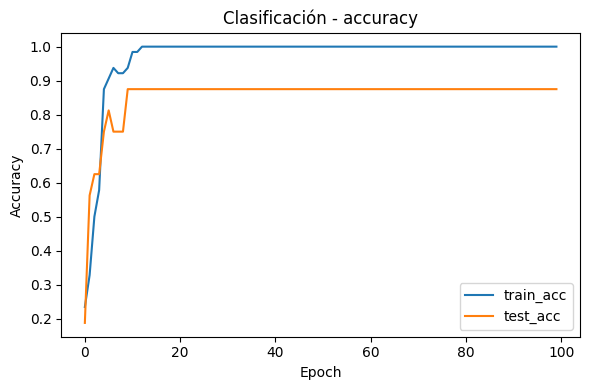

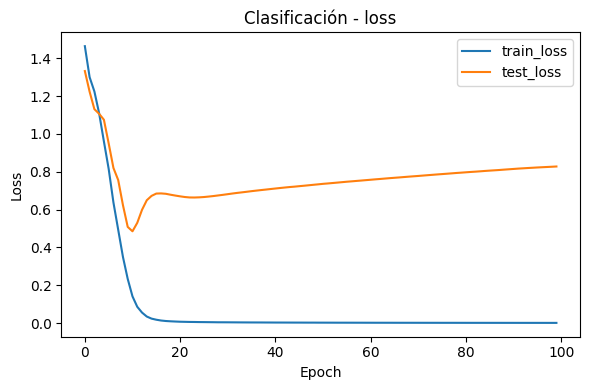

In [21]:

plt.figure(figsize=(6,4))
plt.plot(history_cls["train_acc"], label="train_acc")
plt.plot(history_cls["test_acc"], label="test_acc")
plt.title("Clasificación - accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_cls["train_loss"], label="train_loss")
plt.plot(history_cls["test_loss"], label="test_loss")
plt.title("Clasificación - loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Texto: mañana sube la temperatura en casa
Etiqueta real: clima
Predicción   : comida


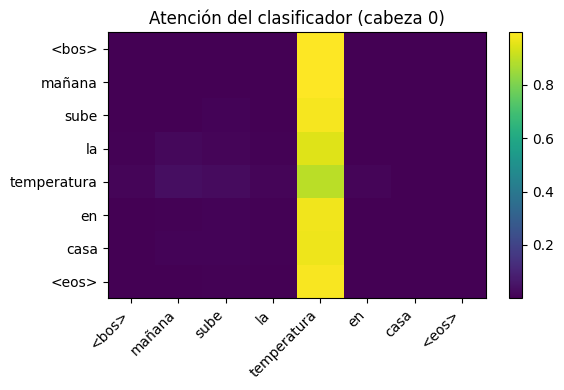

In [22]:

sample_text = test_texts[0]
sample_label = test_labels[0]

ids = [vocab_cls["<bos>"]] + encode(sample_text, vocab_cls) + [vocab_cls["<eos>"]]
ids = ids[:max_len_cls]
mask = [1] * len(ids)
if len(ids) < max_len_cls:
    pad = max_len_cls - len(ids)
    ids += [vocab_cls["<pad>"]] * pad
    mask += [0] * pad

x = torch.tensor([ids], dtype=torch.long).to(device)
m = torch.tensor([mask], dtype=torch.bool).to(device)

model_cls.eval()
with torch.no_grad():
    logits, weights = model_cls(x, m, return_weights=True)
    pred = logits.argmax(dim=-1).item()

tokens_vis = [inv_vocab_cls[i] for i in ids if i != vocab_cls["<pad>"]]
w = weights[0, 0, :len(tokens_vis), :len(tokens_vis)].detach().cpu().numpy()

print("Texto:", sample_text)
print("Etiqueta real:", id_to_label[sample_label])
print("Predicción   :", id_to_label[pred])

plot_matrix(w, xlabels=tokens_vis, ylabels=tokens_vis, title="Atención del clasificador (cabeza 0)")

### Qué observar en la clasificación

Aunque el dataset es muy pequeño y artificial, el modelo aprende a:
- convertir texto en embeddings;
- mezclar contexto con atención;
- resumir la secuencia;
- producir una clase final.

# 9. Ejemplo completo: generación de texto

Ahora usamos un Transformer causal muy pequeño para **predecir el siguiente token**.

La idea es:
- tomar una secuencia;
- ocultar el futuro con causal mask;
- entrenar para que la salida en la posición `t` prediga el token `t+1`.

In [23]:

corpus = [
    "el gato duerme en la casa",
    "el gato mira la luna",
    "el perro corre por el campo",
    "la luna brilla en la noche",
    "el viento mueve las hojas",
    "la noche cubre la ciudad",
    "el mar suena bajo la luna",
    "la casa guarda silencio",
    "el gato corre por la casa",
    "la ciudad duerme en la noche",
    "el perro mira la casa",
    "la luna ilumina el mar",
]

vocab_gen, inv_vocab_gen = build_vocab(corpus)
max_len_gen = max(len(simple_tokenize(t)) for t in corpus) + 2

def encode_gen(text):
    return [vocab_gen["<bos>"]] + encode(text, vocab_gen) + [vocab_gen["<eos>"]]

encoded_corpus = [encode_gen(t) for t in corpus]
print("Vocabulario generación:", len(vocab_gen))
print("Longitud máxima:", max_len_gen)
print("Ejemplo codificado:", encoded_corpus[0])

Vocabulario generación: 30
Longitud máxima: 8
Ejemplo codificado: [2, 5, 8, 11, 9, 4, 6, 3]


In [24]:

class LanguageModelDataset(Dataset):
    def __init__(self, sequences, max_len, pad_id):
        self.data = sequences
        self.max_len = max_len
        self.pad_id = pad_id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = self.data[idx][:self.max_len]
        x = seq[:-1]
        y = seq[1:]

        if len(x) < self.max_len - 1:
            pad = self.max_len - 1 - len(x)
            x = x + [self.pad_id] * pad
            y = y + [self.pad_id] * pad

        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

lm_ds = LanguageModelDataset(encoded_corpus, max_len=max_len_gen, pad_id=vocab_gen["<pad>"])
lm_loader = DataLoader(lm_ds, batch_size=4, shuffle=True)

for xb, yb in lm_loader:
    print("Batch x:", xb.shape, "Batch y:", yb.shape)
    break

Batch x: torch.Size([4, 7]) Batch y: torch.Size([4, 7])


In [25]:

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(causal_mask, -1e9)

        weights = torch.softmax(scores, dim=-1)
        out = weights @ V
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        return out, weights


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_weights=False):
        attn_out, weights = self.attn(x)
        x = self.ln1(x + self.dropout(attn_out))
        x = self.ln2(x + self.dropout(self.ffn(x)))
        if return_weights:
            return x, weights
        return x


class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model=48, n_heads=4, d_ff=96):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional = positional_encoding(max_len, d_model)
        self.block = DecoderBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=0.1)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, return_weights=False):
        h = self.embedding(x) + self.positional[:x.size(1)].to(x.device)
        if return_weights:
            h, weights = self.block(h, return_weights=True)
            logits = self.lm_head(h)
            return logits, weights
        h = self.block(h)
        logits = self.lm_head(h)
        return logits

model_lm = TinyTransformerLM(vocab_size=len(vocab_gen), max_len=max_len_gen).to(device)
criterion_lm = nn.CrossEntropyLoss(ignore_index=vocab_gen["<pad>"])
optimizer_lm = torch.optim.Adam(model_lm.parameters(), lr=3e-3)

history_lm = []
for epoch in range(40):
    model_lm.train()
    losses = []
    for xb, yb in lm_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_lm.zero_grad()
        logits = model_lm(xb)
        loss = criterion_lm(logits.view(-1, logits.size(-1)), yb.view(-1))
        loss.backward()
        optimizer_lm.step()
        losses.append(loss.item())
    mean_loss = float(np.mean(losses))
    history_lm.append(mean_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d} | loss={mean_loss:.4f}")

Epoch 10 | loss=1.0691
Epoch 20 | loss=0.6170
Epoch 30 | loss=0.4798
Epoch 40 | loss=0.4465


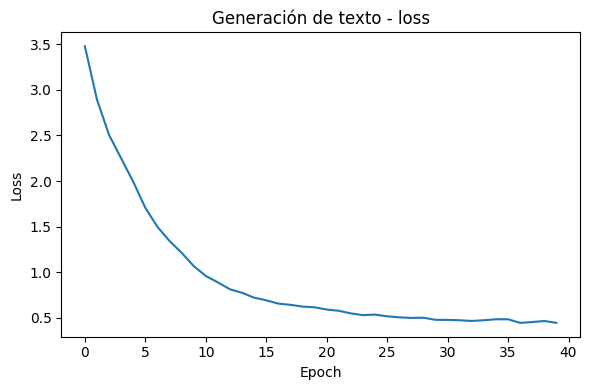

In [26]:

plt.figure(figsize=(6,4))
plt.plot(history_lm)
plt.title("Generación de texto - loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [27]:

def generate_text(model, prompt, vocab, inv_vocab, max_new_tokens=8, temperature=1.0):
    model.eval()
    ids = [vocab["<bos>"]] + encode(prompt, vocab)
    for _ in range(max_new_tokens):
        x = torch.tensor([ids], dtype=torch.long).to(device)
        with torch.no_grad():
            logits = model(x)
            next_token_logits = logits[0, -1] / max(temperature, 1e-6)
            probs = torch.softmax(next_token_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == vocab["<eos>"]:
            break
        ids.append(next_id)

        if len(ids) >= max_len_gen - 1:
            break

    words = [inv_vocab[i] for i in ids[1:] if i not in (vocab["<pad>"], vocab["<eos>"])]
    return " ".join(words)

prompts = ["el gato", "la luna", "el perro", "la ciudad"]
for p in prompts:
    print(f"Prompt: {p!r} -> {generate_text(model_lm, p, vocab_gen, inv_vocab_gen, max_new_tokens=8, temperature=0.9)}")

Prompt: 'el gato' -> el gato duerme en la casa
Prompt: 'la luna' -> la luna ilumina el mar
Prompt: 'el perro' -> el perro mira la casa
Prompt: 'la ciudad' -> la ciudad duerme en la noche


In [ ]:

prompt = "el gato"
ids = [vocab_gen["<bos>"]] + encode(prompt, vocab_gen)
x = torch.tensor([ids], dtype=torch.long).to(device)

model_lm.eval()
with torch.no_grad():
    logits, weights = model_lm(x, return_weights=True)

tokens_vis = [inv_vocab_gen[i] for i in ids]
w = weights[0, 0, :len(tokens_vis), :len(tokens_vis)].detach().cpu().numpy()

print("Prompt:", prompt)
plot_matrix(w, xlabels=tokens_vis, ylabels=tokens_vis, title="Atención causal en generación (cabeza 0)")

### Qué observar en la generación

Este modelo no “entiende” lenguaje de forma profunda: solo aprende patrones del pequeño corpus.  
Aun así, ya se ve la idea central de un modelo autoregresivo:
- mira solo al pasado;
- predice el siguiente token;
- repite el proceso varias veces para generar una secuencia.

# Conclusión

En este notebook se han mostrado, de forma guiada:
- los embeddings;
- la codificación posicional;
- la self-attention;
- las máscaras;
- la multi-head attention;
- la estructura interna de un bloque Transformer;
- un ejemplo de clasificación;
- un ejemplo de generación de texto.

A partir de aquí, el siguiente paso natural sería pasar a:
- un dataset real de clasificación;
- un corpus más grande para generación;
- varias capas Transformer en lugar de una sola.